In [1]:
import numpy as np
from scipy.sparse import spdiags, eye, kron
from scipy.sparse.linalg import spsolve, cg, LinearOperator
import scipy.sparse.linalg as splinalg
import matplotlib.pyplot as plt

In [2]:
def Amult(U, m):
    AU = np.pad(U.reshape((m, m)), ((1,1), (1,1)), 'constant')
    AU[1:-1, 1:-1] = \
        AU[:-2, 1:-1] + \
        AU[1:-1, :-2] + \
        AU[2:, 1:-1] + \
        AU[1:-1, 2:] - \
        4 * AU[1:-1, 1:-1] 
    return - (1+m)**2 * AU[1:-1, 1:-1].reshape(-1)

U = np.array([1,2,3,4])
m = 2
Amult(U, m)

array([-9, 27, 63, 99])

In [3]:
def u_func(x,y):
    return np.sin(4*np.pi*(x+y)) + np.cos(4*np.pi*x*y)

def f_func(x,y):
    term1 = -32*np.pi**2*np.sin(4*np.pi*(x+y))
    term2 = -16*np.pi**2*(x**2 + y**2)*np.cos(4*np.pi*x*y)
    return term1 + term2

def form_rhs(m, f_func, u_func):

    h = 1.0/(m+1)
    b = np.zeros(m*m)

    for j in range(1, m+1):
        for i in range(1, m+1):

            k = (j-1)*m + (i-1)
            x = i*h
            y = j*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 1:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 1:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m:
                b[k] -= u_func(x,1)/h**2

    return b

Succesfull


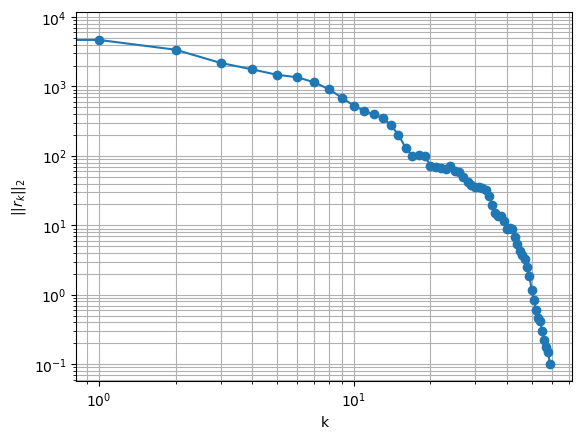

In [ ]:

#ms = [3, 4, 10, 25, 50]
m = 25

errs = []


h = 1 / (m + 1)

F = form_rhs(m,f_func,u_func)
Aminus = LinearOperator(
    shape=(m**2, m**2), 
    matvec=lambda U: Amult(U, m),
    dtype=np.float64
)

residual_norms = []
def residual_norm(xk):
    r_norm = np.linalg.norm(F + Aminus @ xk)
    residual_norms.append(r_norm)

v, info = cg(Aminus, -F, callback = residual_norm)
print(f"{"Succesfull" if info == 0 else str(info) + " iterations"}")

plt.loglog(residual_norms, 'o-')
plt.xlabel("k")
plt.ylabel(r"$||r_k||_2$")
plt.grid(True, which='both')
plt.show()
